# Reproduction des trois figures par optimisation

Ce notebook reproduit les Figures 1, 2 et 3 de `main3.pdf` en **résolvant les problèmes d'optimisation** de l'article avec JuMP et Gurobi.

L'exemple considéré est

$$Q(\xi)=\min_{x,w,\zeta}\left\{\frac14x+w:\frac34x+w\geq\zeta,\ \zeta=\xi,\ x\in\{0,1\},\ w\geq0\right\}.$$

Chaque point des courbes est la valeur optimale d'un modèle. Les expressions analytiques par morceaux ne sont pas utilisées pour produire les données. Les figures sont exportées dans `results/article_figures/`.

In [14]:
import Pkg
Pkg.activate(@__DIR__)

using JuMP
using Gurobi
using Plots
using LaTeXStrings
const MOI = JuMP.MOI

const FIGURE_DIR = joinpath(@__DIR__, "results", "article_figures")
mkpath(FIGURE_DIR)

# Un même environnement Gurobi est partagé par tous les petits modèles.
const GUROBI_ENV = Gurobi.Env()

function new_model()
    model = Model(
        optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.0,
            "DualReductions" => 0,
            "InfUnbdInfo" => 1,
        ),
    )
    set_silent(model)
    return model
end

"""Résout le modèle et renvoie +Inf pour une maximisation non bornée."""
function solve_value!(model; allow_unbounded = false)
    optimize!(model)
    status = termination_status(model)
    if status == MOI.OPTIMAL
        return objective_value(model)
    elseif allow_unbounded && status in (MOI.DUAL_INFEASIBLE, MOI.INFEASIBLE_OR_UNBOUNDED)
        return Inf
    end
    error("Statut Gurobi inattendu : $status")
end

const X_VALUES = (0, 1)
const Z_BINARY = (0, 1)

gr()
default(
    linewidth = 2.4, framestyle = :box, grid = true, gridalpha = 0.25,
    legendfontsize = 9, guidefontsize = 11, tickfontsize = 9,
)

  Activating project at `~/Documents/BinaryRobustOptimization`


ErrorException: cannot declare Main.GUROBI_ENV constant; it already has a value

## Problème de recours original

Cette fonction résout directement le problème définissant $Q(\xi)$. Elle sera utilisée dans les Figures 2 et 3.

In [15]:
function solve_Q(ξ)
    model = new_model()
    @variable(model, x, Bin)
    @variable(model, w >= 0)
    @variable(model, 0 <= ζ <= 1)
    @constraint(model, 3 / 4 * x + w >= ζ)
    @constraint(model, ζ == ξ)
    @objective(model, Min, 1 / 4 * x + w)
    return solve_value!(model)
end

solve_Q (generic function with 1 method)

## Figure 1 — fonctions de valeur lagrangiennes

Pour chaque valeur de $\mu$ ou $\pi$, on résout une minimisation en $(x,w,\zeta)$. L'option `binary_copy` impose $\zeta\in\{0,1\}$ pour les courbes avec un chapeau.

In [16]:
function solve_lagrangian(ξ, multiplier; scalar = false, binary_copy = false)
    model = new_model()
    @variable(model, x, Bin)
    @variable(model, w >= 0)
    @variable(model, 0 <= ζ <= 1)
    binary_copy && set_binary(ζ)
    @constraint(model, 3 / 4 * x + w >= ζ)

    if scalar
        @objective(model, Min, 1 / 4 * x + w + multiplier * (ξ + ζ - 2ξ * ζ))
    else
        @objective(model, Min, 1 / 4 * x + w + multiplier * (ξ - ζ))
    end
    return solve_value!(model)
end

solve_L_prime(μ, ξ) = solve_lagrangian(ξ, μ)
solve_Lhat_prime(μ, ξ) = solve_lagrangian(ξ, μ; binary_copy = true)
solve_L_second(π, ξ) = solve_lagrangian(ξ, π; scalar = true)
solve_Lhat_second(π, ξ) = solve_lagrangian(ξ, π; scalar = true, binary_copy = true)

solve_Lhat_second (generic function with 1 method)

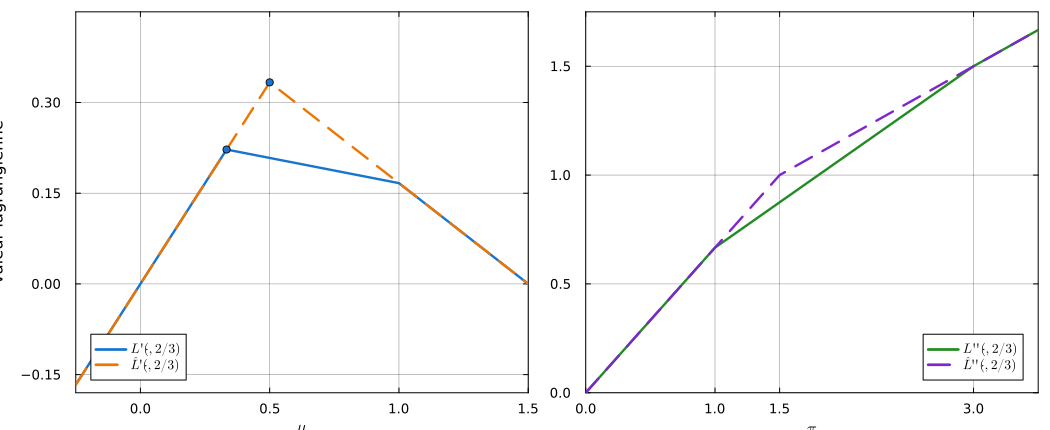

In [17]:
ξ_bar = 2 / 3
# Les points de cassure sont ajoutés aux grilles uniquement pour un tracé net.
μ_grid = sort!(unique!(vcat(collect(range(-0.25, 1.5; length = 151)), [1 / 3, 1 / 2, 1.0])))
π_grid = sort!(unique!(vcat(collect(range(0.0, 3.5; length = 151)), [1.0, 1.5, 3.0])))

L_prime_values = [solve_L_prime(μ, ξ_bar) for μ in μ_grid]
Lhat_prime_values = [solve_Lhat_prime(μ, ξ_bar) for μ in μ_grid]
L_second_values = [solve_L_second(π, ξ_bar) for π in π_grid]
Lhat_second_values = [solve_Lhat_second(π, ξ_bar) for π in π_grid]

p11 = plot(
    μ_grid, L_prime_values;
    label = L"L'(\cdot,2/3)", color = :dodgerblue3,
    xlabel = L"\mu", ylabel = "valeur lagrangienne",
    xlims = (-0.25, 1.5), ylims = (-0.18, 0.45),
    xticks = [0, 0.5, 1, 1.5], yticks = [-0.15, 0, 0.15, 0.30],
    legend = :bottomleft,
)
plot!(p11, μ_grid, Lhat_prime_values;
      label = L"\widehat{L}'(\cdot,2/3)", color = :darkorange2, linestyle = :dash)
scatter!(p11, [1 / 3, 1 / 2],
         [solve_L_prime(1 / 3, ξ_bar), solve_Lhat_prime(1 / 2, ξ_bar)];
         label = "", color = [:dodgerblue3 :darkorange2], markersize = 4)

p12 = plot(
    π_grid, L_second_values;
    label = L"L''(\cdot,2/3)", color = :forestgreen,
    xlabel = L"\pi", xlims = (0, 3.5), ylims = (0, 1.75),
    xticks = [0, 1, 1.5, 3], yticks = [0, 0.5, 1, 1.5],
    legend = :bottomright,
)
plot!(p12, π_grid, Lhat_second_values;
      label = L"\widehat{L}''(\cdot,2/3)", color = :purple3, linestyle = :dash)

figure1 = plot(p11, p12; layout = (1, 2), size = (1050, 430))
savefig(figure1, joinpath(FIGURE_DIR, "figure1_lagrangians.pdf"))
figure1

In [18]:
# Les maxima sont retrouvés numériquement à partir des problèmes résolus.
@assert μ_grid[argmax(L_prime_values)] ≈ 1 / 3
@assert μ_grid[argmax(Lhat_prime_values)] ≈ 1 / 2

## Figure 2 — représentations duales de valeur finie

Les maximisations ci-dessous sont les reformulations mono-niveau obtenues par dualité LP. Pour chaque $x\in\{0,1\}$, $\lambda_x$ dualise la contrainte de capacité et $\sigma_x$ la borne $\zeta\leq1$. Dans la version à copie binaire, les deux valeurs de $\zeta$ sont énumérées, mais la valeur de $w$ reste calculée par son problème dual en $\lambda_{x,\zeta}$.

In [19]:
function solve_Qd_prime(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, μ)
    @variable(model, 0 <= λ[X_VALUES] <= 1)
    @variable(model, σ[X_VALUES] >= 0)
    @constraint(model, [x in X_VALUES], μ <= λ[x] + σ[x])
    @constraint(model, [x in X_VALUES],
        η <= 1 / 4 * x - 3 / 4 * x * λ[x] + μ * ξ - σ[x])
    @objective(model, Max, η)
    return solve_value!(model)
end

function solve_Qdhat_prime(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, μ)
    @variable(model, 0 <= λ[X_VALUES, Z_BINARY] <= 1)
    @constraint(model, [x in X_VALUES, z in Z_BINARY],
        η <= 1 / 4 * x + λ[x, z] * (z - 3 / 4 * x) + μ * (ξ - z))
    @objective(model, Max, η)
    return solve_value!(model)
end

# Les deux formulations scalaires permettent de vérifier la non-bornitude sur (0,1).
function solve_Qd_second(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, π >= 0)
    @variable(model, 0 <= λ[X_VALUES] <= 1)
    @variable(model, σ[X_VALUES] >= 0)
    @constraint(model, [x in X_VALUES], π * (2ξ - 1) <= λ[x] + σ[x])
    @constraint(model, [x in X_VALUES],
        η <= 1 / 4 * x - 3 / 4 * x * λ[x] + π * ξ - σ[x])
    @objective(model, Max, η)
    return solve_value!(model; allow_unbounded = true)
end

function solve_Qdhat_second(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, π >= 0)
    @variable(model, 0 <= λ[X_VALUES, Z_BINARY] <= 1)
    @constraint(model, [x in X_VALUES, z in Z_BINARY],
        η <= 1 / 4 * x + λ[x, z] * (z - 3 / 4 * x) + π * (ξ + z - 2ξ * z))
    @objective(model, Max, η)
    return solve_value!(model; allow_unbounded = true)
end

solve_Qdhat_second (generic function with 1 method)

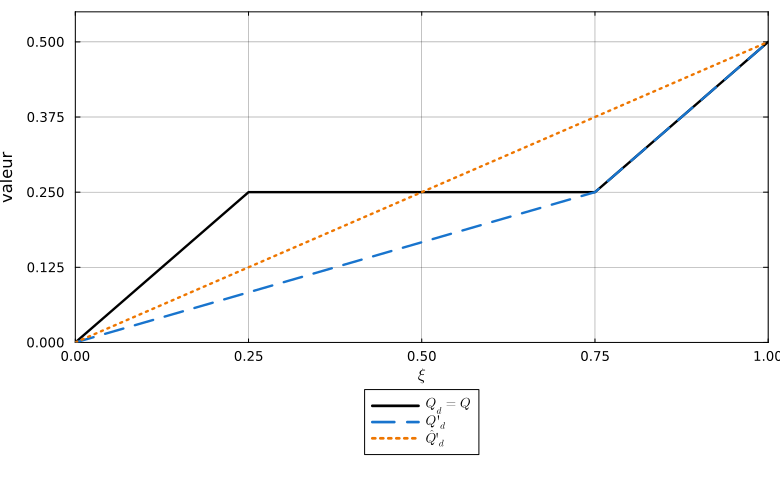

In [20]:
ξ_grid = collect(0.0:0.01:1.0)
Q_values = solve_Q.(ξ_grid)
Qd_prime_values = solve_Qd_prime.(ξ_grid)
Qdhat_prime_values = solve_Qdhat_prime.(ξ_grid)

figure2 = plot(
    ξ_grid, Q_values;
    label = L"Q_d=Q", color = :black,
    xlabel = L"\xi", ylabel = "valeur",
    xlims = (0, 1), ylims = (0, 0.55),
    xticks = 0:0.25:1, yticks = 0:0.125:0.5,
    legend = :outerbottom, size = (780, 500),
)
plot!(figure2, ξ_grid, Qd_prime_values;
      label = L"Q'_d", color = :dodgerblue3, linestyle = :dash)
plot!(figure2, ξ_grid, Qdhat_prime_values;
      label = L"\widehat{Q}'_d", color = :darkorange2, linestyle = :dot)

savefig(figure2, joinpath(FIGURE_DIR, "figure2_dual_representations.pdf"))
figure2

In [25]:
# Contrôles obtenus par de nouvelles résolutions, sans évaluer de formule fermée.
q_prime_at_2_3 = solve_Qd_prime(2 / 3)
q_at_2_3 = solve_Q(2 / 3)
qhat_prime_at_2_3 = solve_Qdhat_prime(2 / 3)
@assert q_prime_at_2_3 < q_at_2_3 < qhat_prime_at_2_3
@assert isinf(solve_Qd_second(2 / 3))
@assert isinf(solve_Qdhat_second(2 / 3))

MethodError: MethodError: no method matching solve_value!(::Model; allow_unbounded::Bool)
This method may not support any kwargs.

Closest candidates are:
  solve_value!(::Any) got unsupported keyword argument "allow_unbounded"
   @ Main ~/Documents/BinaryRobustOptimization/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:28


## Figure 3 — extensions continues des reformulations MILP

On fixe $\underline M=0$, $\overline M=1$, $\mu^M(\xi)=\xi$ et $\pi^M=1$. Chacune des cinq fonctions est calculée en résolvant sa reformulation d'optimisation sur tout $\Xi^{\mathrm{LP}}=[0,1]$.

In [22]:
function solve_Qd_M(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, 0 <= λ[X_VALUES] <= 1)
    @variable(model, δ[X_VALUES])
    @constraint(model, [x in X_VALUES], δ[x] <= λ[x])
    @constraint(model, [x in X_VALUES], δ[x] <= ξ)
    @constraint(model, [x in X_VALUES],
        η <= 1 / 4 * x - 3 / 4 * x * λ[x] + δ[x])
    @objective(model, Max, η)
    return solve_value!(model)
end

function solve_Qd_prime_M(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, 0 <= λ[X_VALUES] <= 1)
    @variable(model, σ[X_VALUES] >= 0)
    @constraint(model, [x in X_VALUES], ξ <= λ[x] + σ[x])
    @constraint(model, [x in X_VALUES],
        η <= 1 / 4 * x - 3 / 4 * x * λ[x] + ξ - σ[x])
    @objective(model, Max, η)
    return solve_value!(model)
end

function solve_Qdhat_prime_M(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, 0 <= λ[X_VALUES, Z_BINARY] <= 1)
    @constraint(model, [x in X_VALUES, z in Z_BINARY],
        η <= 1 / 4 * x + λ[x, z] * (z - 3 / 4 * x) + ξ - ξ * z)
    @objective(model, Max, η)
    return solve_value!(model)
end

function solve_Qd_second_M(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, 0 <= λ[X_VALUES] <= 1)
    @variable(model, σ[X_VALUES] >= 0)
    @constraint(model, [x in X_VALUES], 2ξ - 1 <= λ[x] + σ[x])
    @constraint(model, [x in X_VALUES],
        η <= 1 / 4 * x - 3 / 4 * x * λ[x] + ξ - σ[x])
    @objective(model, Max, η)
    return solve_value!(model)
end

function solve_Qdhat_second_M(ξ)
    model = new_model()
    @variable(model, η)
    @variable(model, 0 <= λ[X_VALUES, Z_BINARY] <= 1)
    @constraint(model, [x in X_VALUES, z in Z_BINARY],
        η <= 1 / 4 * x + λ[x, z] * (z - 3 / 4 * x) + ξ + z - 2ξ * z)
    @objective(model, Max, η)
    return solve_value!(model)
end

solve_Qdhat_second_M (generic function with 1 method)

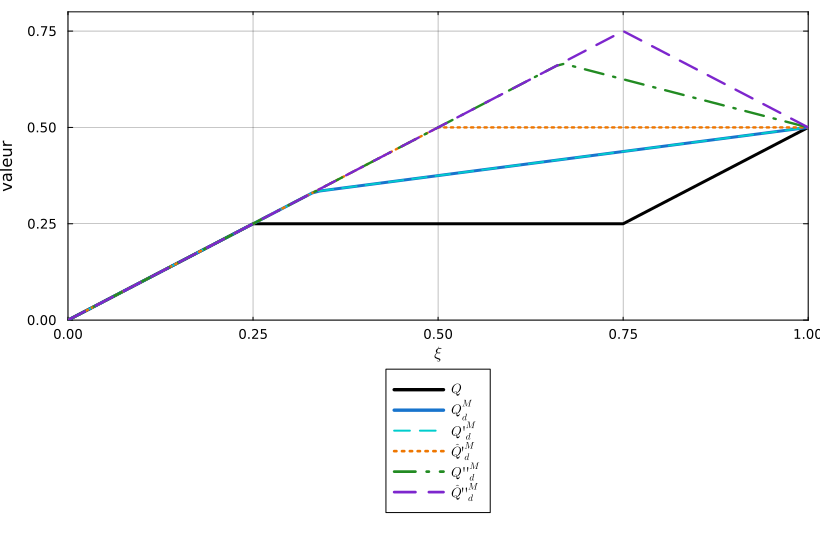

In [23]:
Qd_M_values = solve_Qd_M.(ξ_grid)
Qd_prime_M_values = solve_Qd_prime_M.(ξ_grid)
Qdhat_prime_M_values = solve_Qdhat_prime_M.(ξ_grid)
Qd_second_M_values = solve_Qd_second_M.(ξ_grid)
Qdhat_second_M_values = solve_Qdhat_second_M.(ξ_grid)

figure3 = plot(
    ξ_grid, Q_values;
    label = L"Q", color = :black, linewidth = 3,
    xlabel = L"\xi", ylabel = "valeur",
    xlims = (0, 1), ylims = (0, 0.8),
    xticks = 0:0.25:1, yticks = 0:0.25:0.75,
    legend = :outerbottom, size = (820, 560),
)
plot!(figure3, ξ_grid, Qd_M_values;
      label = L"Q_d^M", color = :dodgerblue3, linewidth = 3)
plot!(figure3, ξ_grid, Qd_prime_M_values;
      label = L"Q'^M_d", color = :cyan3, linestyle = :dash, linewidth = 1.8)
plot!(figure3, ξ_grid, Qdhat_prime_M_values;
      label = L"\widehat{Q}'^M_d", color = :darkorange2, linestyle = :dot)
plot!(figure3, ξ_grid, Qd_second_M_values;
      label = L"Q''^M_d", color = :forestgreen, linestyle = :dashdot)
plot!(figure3, ξ_grid, Qdhat_second_M_values;
      label = L"\widehat{Q}''^M_d", color = :purple3, linestyle = :dash)

savefig(figure3, joinpath(FIGURE_DIR, "figure3_milp_extensions.pdf"))
figure3

In [24]:
# Vérifications numériques des relations de la Proposition 14.
tol = 1e-7
@assert maximum(abs.(Qd_M_values .- Qd_prime_M_values)) <= tol
@assert all(Q_values .<= Qd_M_values .+ tol)
@assert all(Qd_M_values .<= Qdhat_prime_M_values .+ tol)
@assert all(Qdhat_prime_M_values .<= Qd_second_M_values .+ tol)
@assert all(Qd_second_M_values .<= Qdhat_second_M_values .+ tol)
@assert maximum(abs.([Qd_M_values[1], Qd_M_values[end]] .- [Q_values[1], Q_values[end]])) <= tol

### Interprétation

Les résolutions confirment que toutes les reformulations coïncident avec $Q$ sur $\Xi=\{0,1\}$. Sur la relaxation continue, $Q_d^M=Q_d'{}^M$ est la plus forte des cinq reformulations, tandis que $\widehat Q_d''{}^M$ est la plus faible.